In [1]:
from ollama import chat
from ollama import ChatResponse
import pandas as pd
import numpy as np
import os
import json

In [2]:
response: ChatResponse = chat(model='llama3.2:3b', messages=[
  {
    'role': 'user',
    'content': 'Why is the sky blue?',
  },
])
print(response['message']['content'])

ConnectionError: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download

In [3]:
# --- APACHE II Scoring Functions (Simplified) ---
def score_temperature(temp):
    # Temperature in Celsius
    if temp < 30:
        return 4
    elif temp < 32:
        return 3
    elif temp < 34:
        return 2
    elif temp < 36:
        return 1
    elif temp <= 38.4:
        return 0
    elif temp < 39:
        return 0
    elif temp < 41:
        return 1
    elif temp < 42:
        return 2
    else:
        return 4

def score_map(map_val):
    if map_val < 40:
        return 4
    elif map_val < 70:
        return 2
    elif map_val <= 109:
        return 0
    elif map_val <= 129:
        return 2
    else:
        return 4

def score_hr(hr):
    if hr < 40:
        return 4
    elif hr < 55:
        return 3
    elif hr < 70:
        return 2
    elif hr <= 109:
        return 0
    elif hr < 140:
        return 2
    elif hr < 180:
        return 3
    else:
        return 4

def score_rr(rr):
    if rr < 6:
        return 4
    elif rr < 10:
        return 2
    elif rr <= 24:
        return 0
    elif rr <= 34:
        return 1
    elif rr <= 49:
        return 3
    else:
        return 4

def score_oxygenation(pao2, fiO2):
    # Use PaO2 thresholds if FiO2 <= 0.5, otherwise use a simplified PF ratio cutoff
    if fiO2 <= 0.5:
        if pao2 >= 70:
            return 0
        elif pao2 >= 61:
            return 2
        elif pao2 >= 55:
            return 3
        else:
            return 4
    else:
        pf = pao2 / fiO2 if fiO2 > 0 else 0
        if pf >= 200:
            return 0
        elif pf >= 150:
            return 2
        elif pf >= 100:
            return 3
        else:
            return 4

def score_ph(ph):
    # Using typical APACHE II cutoffs for arterial pH
    if ph >= 7.7:
        return 4
    elif ph >= 7.6:
        return 3
    elif ph >= 7.5:
        return 1
    elif ph >= 7.33:
        return 0
    elif ph >= 7.25:
        return 2
    elif ph >= 7.15:
        return 3
    else:
        return 4

def score_na(na):
    if na >= 180:
        return 4
    elif 160 <= na < 180:
        return 3
    elif 155 <= na < 160:
        return 2
    elif 150 <= na < 155:
        return 1
    elif 130 <= na < 150:
        return 0
    elif 120 <= na < 130:
        return 2
    elif 111 <= na < 120:
        return 3
    else:  # na < 111
        return 4

def score_k(k):
    if k >= 7:
        return 4
    elif 6 <= k < 7:
        return 3
    elif 5.5 <= k < 6:
        return 1
    elif 3.5 <= k < 5.5:
        return 0
    elif 3.0 <= k < 3.5:
        return 1
    elif 2.5 <= k < 3.0:
        return 2
    else:
        return 4

def score_creatinine(cr):
    if cr >= 3.5:
        return 4
    elif cr >= 2.0:
        return 3
    elif cr >= 1.5:
        return 2
    elif cr >= 0.6:
        return 0
    else:
        return 2

def score_hct(hct):
    if hct >= 60:
        return 4
    elif hct >= 50:
        return 2
    elif hct >= 46:
        return 1
    elif hct >= 30:
        return 0
    elif hct >= 20:
        return 2
    else:
        return 4

def score_wbc(wbc):
    if wbc >= 40:
        return 4
    elif wbc >= 20:
        return 2
    elif wbc >= 15:
        return 1
    elif wbc >= 3:
        return 0
    elif wbc >= 1:
        return 2
    else:
        return 4

def score_gcs(gcs):
    # In APACHE II, the GCS component is 15 - GCS, capped at a maximum of 13.
    return min(15 - gcs, 13)

def score_age(age):
    if age < 45:
        return 0
    elif age < 55:
        return 2
    elif age < 65:
        return 3
    elif age < 75:
        return 5
    else:
        return 6

def compute_apache2(row):
    temp_score = score_temperature(row['Temp'])
    map_score = score_map(row['MAP'])
    hr_score = score_hr(row['HR'])
    rr_score = score_rr(row['RespRate'])
    oxy_score = score_oxygenation(row['PaO2'], row['FiO2'])
    ph_score = score_ph(row['pH'])
    na_score = score_na(row['Na'])
    k_score = score_k(row['K'])
    cr_score = score_creatinine(row['Creatinine'])
    hct_score = score_hct(row['HCT'])
    wbc_score = score_wbc(row['WBC'])
    gcs_score = score_gcs(row['GCS'])
    age_score = score_age(row['Age'])
    
    # Note: Chronic Health Points are not available in this dataset.
    return (temp_score + map_score + hr_score + rr_score + oxy_score +
            ph_score + na_score + k_score + cr_score + hct_score +
            wbc_score + gcs_score + age_score)

# --- SOFA Scoring Functions (Simplified) ---
def score_sofa_respiratory(row):
    # Compute the PaO2/FiO2 ratio
    fiO2 = row['FiO2']
    pao2 = row['PaO2']
    pf = pao2 / fiO2 if fiO2 > 0 else 0
    # If patient is on mechanical ventilation (assumed MechVent==1), use the following thresholds:
    if row['MechVent'] == 1 or row['MechVent'] == 1.0:
        if pf >= 400:
            return 0
        elif pf >= 300:
            return 1
        elif pf >= 200:
            return 2
        elif pf >= 100:
            return 3
        else:
            return 4
    else:
        # If not ventilated, we use similar thresholds (this can be adjusted as needed)
        if pf >= 400:
            return 0
        elif pf >= 300:
            return 1
        elif pf >= 200:
            return 2
        elif pf >= 100:
            return 3
        else:
            return 4

def score_sofa_coagulation(platelets):
    if platelets >= 150:
        return 0
    elif platelets >= 100:
        return 1
    elif platelets >= 50:
        return 2
    elif platelets >= 20:
        return 3
    else:
        return 4

def score_sofa_liver(bilirubin):
    if bilirubin < 1.2:
        return 0
    elif bilirubin < 2.0:
        return 1
    elif bilirubin < 6.0:
        return 2
    elif bilirubin < 12.0:
        return 3
    else:
        return 4

def score_sofa_cardiovascular(map_val):
    # Simplified version: using only MAP (without vasopressor doses)
    return 0 if map_val >= 70 else 1

def score_sofa_cns(gcs):
    if gcs == 15:
        return 0
    elif gcs >= 13:
        return 1
    elif gcs >= 10:
        return 2
    elif gcs >= 6:
        return 3
    else:
        return 4

def score_sofa_renal(creatinine, urine):
    # Using creatinine thresholds; urine output could be used if available
    if creatinine < 1.2:
        return 0
    elif creatinine < 2.0:
        return 1
    elif creatinine < 3.5:
        return 2
    elif creatinine < 5.0:
        return 3
    else:
        return 4

def compute_sofa(row):
    resp = score_sofa_respiratory(row)
    coag = score_sofa_coagulation(row['Platelets'])
    liver = score_sofa_liver(row['Bilirubin'])
    cardio = score_sofa_cardiovascular(row['MAP'])
    cns = score_sofa_cns(row['GCS'])
    renal = score_sofa_renal(row['Creatinine'], row['Urine'])
    return resp + coag + liver + cardio + cns + renal

# --- Individual Derived Metrics ---
def compute_pf_ratio(row):
    return row['PaO2'] / row['FiO2'] if row['FiO2'] > 0 else None

def compute_shock_index(row):
    return row['HR'] / row['SysABP'] if row['SysABP'] > 0 else None

def compute_map_calc(row):
    # Recompute MAP from SysABP and DiasABP
    return (2 * row['DiasABP'] + row['SysABP']) / 3

def compute_oxygenation_index(row):
    # Oxygenation Index = (FiO2 * MAP * 100) / PaO2
    return (row['FiO2'] * row['MAP'] * 100) / row['PaO2'] if row['PaO2'] > 0 else None

def compute_bun_creatinine_ratio(row):
    return row['BUN'] / row['Creatinine'] if row['Creatinine'] > 0 else None


In [4]:
print(os.getcwd())
raw_val = pd.read_csv('hcml_projects/task_1/dataframes/raw_val.csv')
raw_val.groupby('PatientID')
patientID = raw_val["PatientID"][0]
print(patientID)
filteredDF = raw_val[raw_val["PatientID"] == patientID]
filteredDF

/home/adsuma
142675


,PatientID,Hour,ALP,ALT,AST,Age,Albumin,BUN,Bilirubin,Cholesterol,...,RespRate,SaO2,SysABP,Temp,TroponinI,TroponinT,Urine,WBC,Weight,pH
0,142675,0.0,79.0,30.0,44.0,70.0,3.0,19.0,0.7,155.0,...,19.0,98.0,117.0,37.0,2.0,0.13,80.0,11.4,85.0,7.50
1,142675,1.0,79.0,30.0,44.0,70.0,3.0,19.0,0.7,155.0,...,19.0,98.0,104.0,35.7,2.0,0.13,80.0,11.4,85.0,7.50
2,142675,2.0,79.0,30.0,44.0,70.0,3.0,13.0,0.7,155.0,...,19.0,98.0,147.0,35.8,2.0,0.13,300.0,11.4,85.0,7.50
3,142675,3.0,79.0,30.0,44.0,70.0,3.0,13.0,0.7,155.0,...,19.0,98.0,128.0,35.8,2.0,0.13,380.0,11.4,85.0,7.43
4,142675,4.0,79.0,30.0,44.0,70.0,3.0,13.0,0.7,155.0,...,19.0,98.0,0.0,33.4,2.0,0.13,200.0,11.4,85.0,7.36
5,142675,5.0,79.0,30.0,44.0,70.0,3.0,9.0,0.7,155.0,...,19.0,98.0,0.0,33.4,2.0,0.13,300.0,7.9,85.0,7.34
6,142675,6.0,79.0,30.0,44.0,70.0,3.0,9.0,0.7,155.0,...,19.0,98.0,0.0,33.4,2.0,0.13,300.0,7.9,85.0,7.42
7,142675,7.0,79.0,30.0,44.0,70.0,3.0,9.0,0.7,155.0,...,19.0,98.0,79.0,33.4,2.0,0.13,300.0,7.9,85.0,7.42
8,142675,8.0,24.0,30.0,44.0,70.0,1.7,12.0,0.9,155.0,...,19.0,98.0,0.0,34.6,2.0,0.13,300.0,8.7,85.0,7.45
9,142675,9.0,24.0,30.0,44.0,70.0,1.7,12.0,0.9,155.0,...,19.0,98.0,0.0,35.3,2.0,0.13,300.0,8.7,85.0,7.37


In [5]:
df = pd.DataFrame()
df['APACHE_II'] = filteredDF.apply(compute_apache2, axis=1)
df['SOFA'] = filteredDF.apply(compute_sofa, axis=1)
print(df['APACHE_II'].mean(), df['SOFA'].mean())

raw_val['APACHE_II'] = raw_val.apply(compute_apache2, axis=1)
raw_val['SOFA'] = raw_val.apply(compute_sofa, axis=1)
raw_val['OxygenationIndex'] = raw_val.apply(compute_oxygenation_index, axis=1)
raw_val['BUN_Creatinine_Ratio'] = raw_val.apply(compute_bun_creatinine_ratio, axis=1)
raw_val['PF_Ratio'] = raw_val.apply(compute_pf_ratio, axis=1)
raw_val['ShockIndex'] = raw_val.apply(compute_shock_index, axis=1)
raw_val['MAP_Calc'] = raw_val.apply(compute_map_calc, axis=1)

aggragatedDF = raw_val.groupby('PatientID')
meanDF = aggragatedDF.mean().reset_index()[['PatientID','APACHE_II', 'SOFA', 'PF_Ratio', 'OxygenationIndex', 'BUN_Creatinine_Ratio', 'ShockIndex', 'MAP_Calc']]
meanDF.columns = ['PatientID', 'Mean_APACHE_II', 'Mean_SOFA', 'Mean_PF_Ratio', 'Mean_OxygenationIndex', 'Mean_BUN_Creatinine_Ratio', 'Mean_ShockIndex', 'Mean_MAP_Calc']
meanDF
minDF = aggragatedDF.min().reset_index()[['PatientID','APACHE_II', 'SOFA', 'PF_Ratio', 'OxygenationIndex', 'BUN_Creatinine_Ratio', 'ShockIndex', 'MAP_Calc']]
minDF.columns = ['PatientID', 'Min_APACHE_II', 'Min_SOFA', 'Min_PF_Ratio', 'Min_OxygenationIndex', 'Min_BUN_Creatinine_Ratio', 'Min_ShockIndex', 'Min_MAP_Calc']
minDF
maxDF = aggragatedDF.max().reset_index()[['PatientID','APACHE_II', 'SOFA', 'PF_Ratio', 'OxygenationIndex', 'BUN_Creatinine_Ratio', 'ShockIndex', 'MAP_Calc']]
maxDF.columns = ['PatientID', 'Max_APACHE_II', 'Max_SOFA', 'Max_PF_Ratio', 'Max_OxygenationIndex', 'Max_BUN_Creatinine_Ratio', 'Max_ShockIndex', 'Max_MAP_Calc']
maxDF
finalDF = pd.merge(meanDF, minDF, on='PatientID')
finalDF = pd.merge(finalDF, maxDF, on='PatientID')
finalDF


22.897959183673468 9.306122448979592


,PatientID,Mean_APACHE_II,Mean_SOFA,Mean_PF_Ratio,Mean_OxygenationIndex,Mean_BUN_Creatinine_Ratio,Mean_ShockIndex,Mean_MAP_Calc,Min_APACHE_II,Min_SOFA,...,Min_BUN_Creatinine_Ratio,Min_ShockIndex,Min_MAP_Calc,Max_APACHE_II,Max_SOFA,Max_PF_Ratio,Max_OxygenationIndex,Max_BUN_Creatinine_Ratio,Max_ShockIndex,Max_MAP_Calc
0,142675,22.897959,9.306122,341.938776,38.706791,13.037053,0.407817,34.877551,7.0,1,...,11.428571,0.000000,0.000000,31.0,15,948.000000,158.000000,21.111111,0.878049,103.000000
1,142676,6.673469,2.102041,228.000000,34.210526,59.453515,0.767486,77.666667,4.0,2,...,21.111111,0.615385,77.666667,8.0,3,228.000000,34.210526,80.000000,0.931624,77.666667
2,142680,12.795918,5.714286,163.932945,59.306069,31.029316,0.723881,75.904762,4.0,3,...,21.111111,0.452991,0.000000,20.0,8,336.666667,150.666667,32.857143,1.050505,111.666667
3,142683,20.489796,9.163265,158.325335,65.473554,12.633625,0.637146,78.986395,4.0,1,...,10.000000,0.449664,56.000000,27.0,12,588.000000,143.636364,21.111111,0.906250,112.000000
4,142688,4.714286,2.734694,176.081633,45.897232,23.203758,0.870764,77.061224,3.0,2,...,21.111111,0.752137,69.333333,9.0,4,228.000000,68.421053,27.142857,1.056075,90.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,152849,12.857143,4.714286,189.986152,60.136560,24.268707,0.755670,85.986395,7.0,1,...,20.833333,0.620482,68.333333,24.0,9,748.000000,118.196721,27.777778,1.122449,104.666667
3996,152851,23.183673,8.102041,161.469388,46.881990,25.835030,0.708103,70.258503,14.0,5,...,19.600000,0.523810,0.000000,30.0,10,228.000000,78.571429,31.578947,1.105882,93.333333
3997,152858,8.877551,3.183673,225.551020,35.792225,18.262238,0.621931,79.306122,7.0,3,...,17.058824,0.527132,70.333333,11.0,4,254.000000,43.055556,21.111111,0.769841,92.666667
3998,152862,5.571429,2.959184,147.551020,58.881750,22.779397,0.951334,77.666667,4.0,1,...,17.142857,0.735043,77.666667,9.0,4,378.000000,102.631579,26.666667,1.162393,77.666667


In [ ]:
import re

def extractNumericValue(value):
    # Extract numeric value from the string
    match = re.search(r'\d+(\.\d+)?', str(value))
    if match:
        return int(match.group(0))
    else:
        return None

def prompt1to10(patient: pd.DataFrame, extractEmbeddings: bool = False):
    context = "Use the patient’s average APACHE II and SOFA to estimate mortality risk on a scale from 1 (very low risk) to 10 (very high risk). " \
    "Remember that higher APACHE II (e.g., above 25) and higher SOFA (e.g., above 15) scores correlate with significantly increased mortality." \
    "Keep in mind that many patients SURVIVE even with moderate or elevated scores, so lean toward assigning lower risk values (under 4) unless both scores are extremely high!\n"
    context += "Will the following patient die in the next 48 hours given the following metrics? GIVE ME only the response from 1 to 10 as a numerical value! Keep the reasoning short\n"
    
    prompt = f"PatientID: {patient['PatientID']}, Mean APACHE-II Score: {patient['Mean_APACHE_II']}, Mean SOFA Score: {patient['Mean_SOFA']}\n"
    response = chat(model='llama3.2:3b', messages=[
    {
        'role': 'user',
        'content': f'{context}{prompt}',
    },
    ])
    n = extractNumericValue(response['message']['content'])
    print(f'{response["message"]["content"]} \n EXTRACTED NUMBER:{n}')
    return n

In [25]:
deathDF = pd.DataFrame(columns=['PatientID', 'Death'])

batch_size = 1
for i in range(0, 50, batch_size):
    retry = 5
    while(retry > 0):
        try:
            batch = meanDF.iloc[i:i+batch_size]
            prompt = "Will the following patient die in the next 48 hours given the following metrics? Respond with '1' if he died or '0'.GIVE ME the response as 1 or 0\n"
            for row in batch.iterrows():
                prompt += f"Patient {row[1]['PatientID']}: average APACHE II {row[1]['Mean_APACHE_II']}, average SOFA {row[1]['Mean_SOFA']}\n"
            response = chat(model='llama3.2:3b', messages=[
            {
                'role': 'user',
                'content': prompt,
            },
            ])
            results = json.loads(response['message']['content'])
            
            batch_ids = batch['PatientID'].tolist()
            batch_results = pd.DataFrame({'PatientID': batch_ids, 'Death': results})
            print(f'{i}/{len(meanDF)}')
            print(results)
            deathDF = pd.concat([deathDF, batch_results], ignore_index=True)
            retry = 0
        except Exception as e:
            print(f'Error: {e}\n Retrying...{retry}')
            retry -= 1

0/4000
1
1/4000
1
2/4000
0


KeyboardInterrupt: 

In [29]:
def predictDeath(patientsDF, limit=200):
    deathDF = pd.DataFrame(columns=['PatientID', 'Death'])

    # Loop through the first 200 patients
    for i in range(0, limit):
        retry = 5
        while(retry > 0):
            try:
                patient = patientsDF.iloc[i]
                n = prompt1to10(patient)
                n = 1 if n > 5 else 0

                deathDF = pd.concat([deathDF, pd.DataFrame({'PatientID': [patient['PatientID']], 'Death': [n]})], ignore_index=True)
                print(f'{i}/{len(patientsDF)}')
                retry = 0
            except Exception as e:
                print(f'Error: {e}\n Retrying...{retry}')
                retry -= 1
    return deathDF

deathDF = predictDeath(meanDF, 200)


6 
 EXTRACTED NUMBER:6
0/4000


/var/folders/kx/45_n67vs6_z3s8j5019ns3qw0000gn/T/ipykernel_12895/3738200270.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  deathDF = pd.concat([deathDF, pd.DataFrame({'PatientID': [patient['PatientID']], 'Death': [n]})], ignore_index=True)


4 
 EXTRACTED NUMBER:4
1/4000
6 
 EXTRACTED NUMBER:6
2/4000
6 
 EXTRACTED NUMBER:6
3/4000
7 
 EXTRACTED NUMBER:7
4/4000
6 
 EXTRACTED NUMBER:6
5/4000
6 
 EXTRACTED NUMBER:6
6/4000
6 
 EXTRACTED NUMBER:6
7/4000
6 
 EXTRACTED NUMBER:6
8/4000
5 
 EXTRACTED NUMBER:5
9/4000
4 
 EXTRACTED NUMBER:4
10/4000
6 
 EXTRACTED NUMBER:6
11/4000
6 
 EXTRACTED NUMBER:6
12/4000
5 
 EXTRACTED NUMBER:5
13/4000
7 
 EXTRACTED NUMBER:7
14/4000
4 
 EXTRACTED NUMBER:4
15/4000
4 
 EXTRACTED NUMBER:4
16/4000
4 
 EXTRACTED NUMBER:4
17/4000
6 
 EXTRACTED NUMBER:6
18/4000
6 
 EXTRACTED NUMBER:6
19/4000
6 
 EXTRACTED NUMBER:6
20/4000
4 
 EXTRACTED NUMBER:4
21/4000
6 
 EXTRACTED NUMBER:6
22/4000
4 
 EXTRACTED NUMBER:4
23/4000
6 
 EXTRACTED NUMBER:6
24/4000
7 
 EXTRACTED NUMBER:7
25/4000
7 
 EXTRACTED NUMBER:7
26/4000
6 
 EXTRACTED NUMBER:6
27/4000
5 
 EXTRACTED NUMBER:5
28/4000
6 
 EXTRACTED NUMBER:6
29/4000
4 
 EXTRACTED NUMBER:4
30/4000
6 
 EXTRACTED NUMBER:6
31/4000
6 
 EXTRACTED NUMBER:6
32/4000
4 
 EXTRACTED NUM

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

targetDF = pd.read_csv('ml4h_data/p1/Outcomes-b.txt')
print(targetDF.head(2))
targetDF = targetDF[['RecordID', 'In-hospital_death', 'SOFA']]
targetDF.columns = ['PatientID', 'Death', 'SOFA']

   RecordID  SAPS-I  SOFA  Length_of_stay  Survival  In-hospital_death
0    142675      27    14               9         7                  1
1    142676      12     1              31       468                  0


   PatientID Death
0   142675.0     1
1   142676.0     0


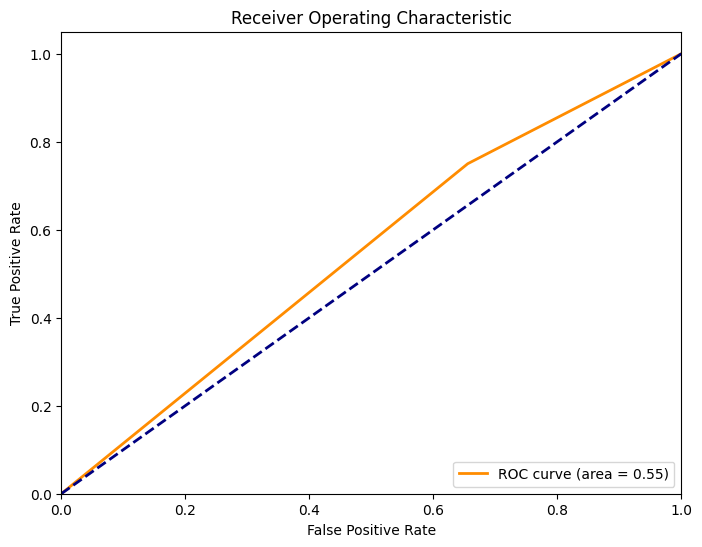

In [31]:
mergedDF = pd.merge(deathDF, targetDF, on='PatientID', suffixes=('_pred', '_true'))
print(deathDF.head(2))
y_true = mergedDF['Death_true']
y_score = mergedDF['Death_pred']

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.close()
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

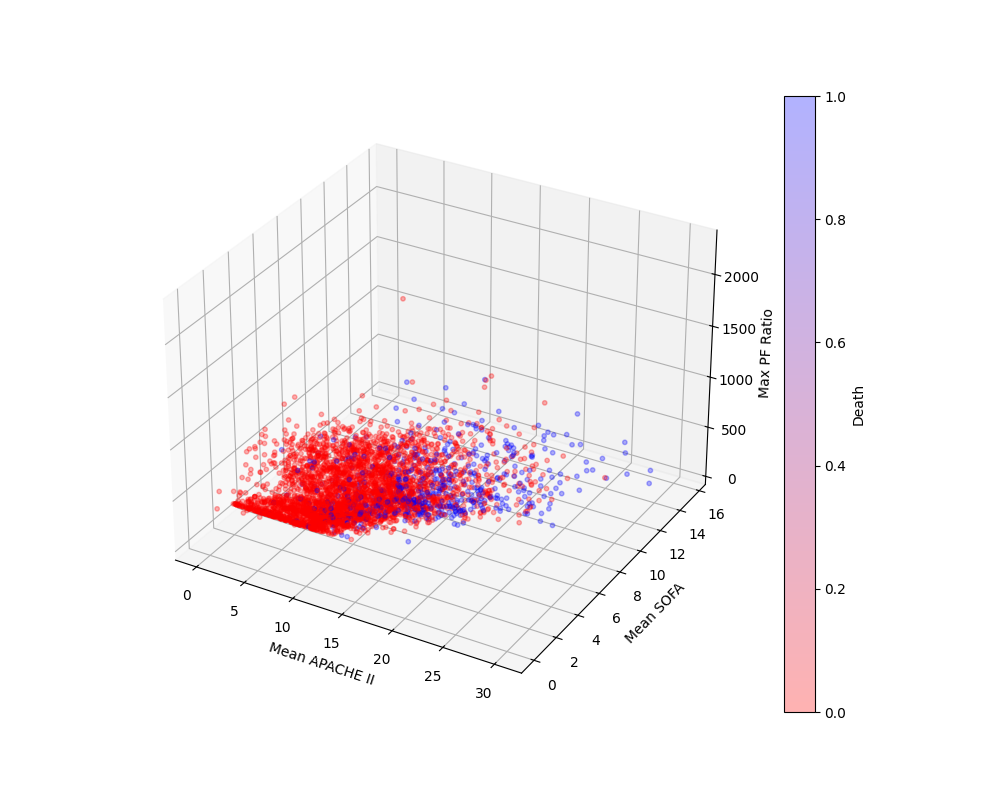

In [32]:
import matplotlib.colors as mcolors
%matplotlib widget
red_blue = mcolors.LinearSegmentedColormap.from_list('red_blue', ['red', 'blue'])

plt.close()
plt.close()

df = pd.merge(finalDF, targetDF, on='PatientID', suffixes=('_pred', '_true'))
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df['Mean_APACHE_II'], df['Mean_SOFA'], df['Max_PF_Ratio'], c=df['Death'], cmap=red_blue, alpha=0.3, s=10)

ax.set_xlabel('Mean APACHE II')
ax.set_ylabel('Mean SOFA')
ax.set_zlabel('Max PF Ratio')
plt.colorbar(sc, label='Death')

plt.show()

<h3>To do:</h3> 
<ul>
<li>
add the 1-10 stuff
</li>
<li>
add in context learning (teach it how to segment stuff before)
</li>
<li>
retrieve embeddings
</li>
<li>
use time series foundation models
</li>
<li>
check sofa score threshold
</li>
</ul>

<h2>Q4.2 Using LLMs to retrieve embeddings (3 Pts)</h2>

In [7]:
import ollama
import numpy as np

def getPatientEmbedding(patient):
    inp = f"Patient has mean APACHE-II Score: {patient['Mean_APACHE_II']} and mean SOFA Score: {patient['Mean_SOFA']}\n"
    response = ollama.embed(
        model='all-minilm',
        input=inp,
    )
    return response['embeddings'][0]

def extractEmbeddings(patientsDF, limit=200):
    embeddingsDF = pd.DataFrame(columns=['PatientID', 'Embedding'])

    # Loop through the first 200 patients
    for i in range(0, limit):
        retry = 5
        while(retry > 0):
            try:
                patient = patientsDF.iloc[i]
                emb = getPatientEmbedding(patient)

                embeddingsDF = pd.concat([embeddingsDF, pd.DataFrame({'PatientID': [patient['PatientID']], 'Embedding': [emb]})], ignore_index=True)
                print(f'{i}/{len(patientsDF)}')
                retry = 0
            except Exception as e:
                print(f'Error: {e}\n Retrying...{retry}')
                retry -= 1
    return embeddingsDF

def extractDF(csv_file, outcomes_file):
    raw = pd.read_csv(csv_file)
    raw['APACHE_II'] = raw.apply(compute_apache2, axis=1)
    raw['SOFA'] = raw.apply(compute_sofa, axis=1)
    raw['OxygenationIndex'] = raw.apply(compute_oxygenation_index, axis=1)
    raw['BUN_Creatinine_Ratio'] = raw.apply(compute_bun_creatinine_ratio, axis=1)
    raw['PF_Ratio'] = raw.apply(compute_pf_ratio, axis=1)
    raw['ShockIndex'] = raw.apply(compute_shock_index, axis=1)
    raw['MAP_Calc'] = raw.apply(compute_map_calc, axis=1)

    aggragatedDF = raw.groupby('PatientID')
    meanDF = aggragatedDF.mean().reset_index()[['PatientID','APACHE_II', 'SOFA', 'PF_Ratio', 'OxygenationIndex', 'BUN_Creatinine_Ratio', 'ShockIndex', 'MAP_Calc']]
    meanDF.columns = ['PatientID', 'Mean_APACHE_II', 'Mean_SOFA', 'Mean_PF_Ratio', 'Mean_OxygenationIndex', 'Mean_BUN_Creatinine_Ratio', 'Mean_ShockIndex', 'Mean_MAP_Calc']
    meanDF
    minDF = aggragatedDF.min().reset_index()[['PatientID','APACHE_II', 'SOFA', 'PF_Ratio', 'OxygenationIndex', 'BUN_Creatinine_Ratio', 'ShockIndex', 'MAP_Calc']]
    minDF.columns = ['PatientID', 'Min_APACHE_II', 'Min_SOFA', 'Min_PF_Ratio', 'Min_OxygenationIndex', 'Min_BUN_Creatinine_Ratio', 'Min_ShockIndex', 'Min_MAP_Calc']
    minDF
    maxDF = aggragatedDF.max().reset_index()[['PatientID','APACHE_II', 'SOFA', 'PF_Ratio', 'OxygenationIndex', 'BUN_Creatinine_Ratio', 'ShockIndex', 'MAP_Calc']]
    maxDF.columns = ['PatientID', 'Max_APACHE_II', 'Max_SOFA', 'Max_PF_Ratio', 'Max_OxygenationIndex', 'Max_BUN_Creatinine_Ratio', 'Max_ShockIndex', 'Max_MAP_Calc']
    maxDF
    finalDF = pd.merge(meanDF, minDF, on='PatientID')
    finalDF = pd.merge(finalDF, maxDF, on='PatientID')

    outcomesDF = pd.read_csv(outcomes_file)
    outcomesDF = outcomesDF[['RecordID', 'In-hospital_death']]
    outcomesDF.columns = ['PatientID', 'Death']
    finalDF = pd.merge(finalDF, outcomesDF, on='PatientID', suffixes=('_pred', '_true'))
    return finalDF, raw

In [8]:
trainPatientsDF = extractDF('hcml_projects/task_1/dataframes/raw_train.csv', 'ml4h_data/p1/Outcomes-a.txt')[0]
testPatientsDF = extractDF('hcml_projects/task_1/dataframes/raw_test.csv', 'ml4h_data/p1/Outcomes-c.txt')[0]

# trainEmbeddingsDF = extractEmbeddings(trainPatientsDF, len(trainPatientsDF))
# testEmbeddingsDF = extractEmbeddings(testPatientsDF, len(testPatientsDF))

In [55]:
trainDF = pd.merge(trainPatientsDF, trainEmbeddingsDF, on='PatientID', suffixes=('_pred', '_true'))
trainDF = trainDF[['PatientID', 'Embedding', 'Death']]

testDF = pd.merge(testPatientsDF, testEmbeddingsDF, on='PatientID', suffixes=('_pred', '_true'))
testDF = testDF[['PatientID', 'Embedding', 'Death']]

trainDF

,PatientID,Embedding,Death
0,132539,"[0.06000663, -0.025964398, -0.030653091, -0.03...",0
1,132540,"[0.07054011, -0.039332006, -0.039523687, -0.04...",0
2,132541,"[0.06243336, -0.022967024, -0.027334305, -0.04...",0
3,132543,"[0.074736856, -0.0314576, -0.028168226, -0.035...",0
4,132545,"[0.07324343, -0.039173983, -0.036681436, -0.03...",0
...,...,...,...
3995,142665,"[0.07485705, -0.027044196, -0.030889794, -0.03...",0
3996,142667,"[0.0734291, -0.030198995, -0.031371582, -0.036...",0
3997,142670,"[0.07289518, -0.03648125, -0.03136923, -0.0327...",0
3998,142671,"[0.07823331, -0.024170212, -0.036559932, -0.04...",1


Test Accuracy: 0.85375


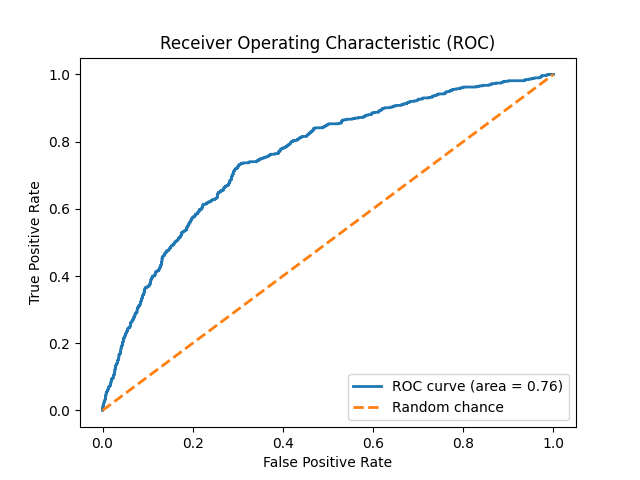

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc


X_train = np.array([np.array(x) for x in trainDF['Embedding']])
X_test = np.array([np.array(x) for x in testDF['Embedding']])
y_train = trainDF['Death'].values
y_test = testDF['Death'].values

model = LogisticRegression(max_iter=1000, solver='lbfgs')  # increase max_iter if needed
model.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

y_pred_proba = model.predict_proba(X_test)[:, 1]

# Compute the false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve using matplotlib
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

In [80]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=80, learning_rate=200, random_state=42)
embeddings_2d = tsne.fit_transform(np.array(testDF['Embedding'].tolist()))

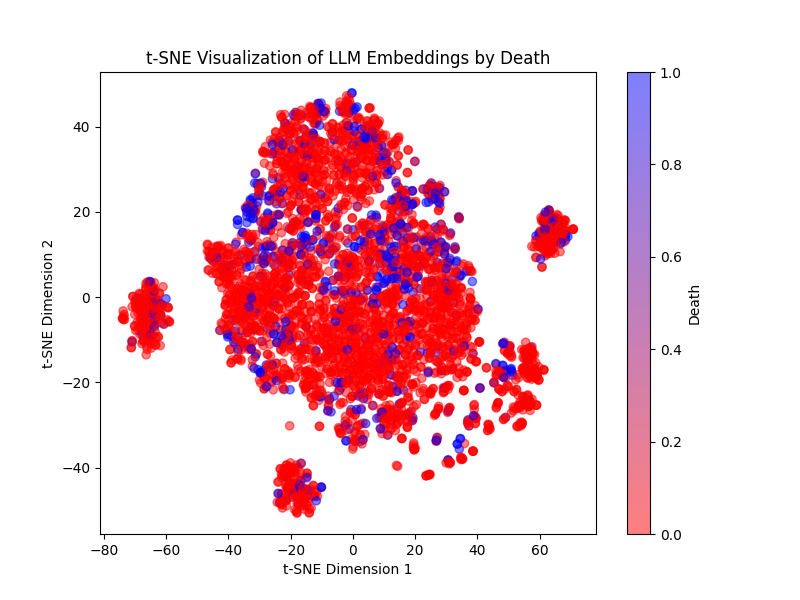

In [81]:
plt.close()
plt.figure(figsize=(8, 6))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=testDF['Death'], cmap=red_blue, alpha=0.5)
plt.title("t-SNE Visualization of LLM Embeddings by Death")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(scatter, label="Death")
plt.show()

<h2>Q4.3 Using time-series foundation models (5 Pts)</h2>

In [ ]:
#  -------------- Code Snippet for Chronos T5 Small ----------------

import torch
from chronos import ChronosPipeline

pipeline = ChronosPipeline.from_pretrained(
  "amazon/chronos-t5-small",
  device_map="cuda",
  torch_dtype=torch.bfloat16,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/AileenNielsen/TimeSeriesAnalysisWithPython/master/data/AirPassengers.csv")

# context must be either a 1D tensor, a list of 1D tensors,
# or a left-padded 2D tensor with batch as the first dimension
context = torch.tensor(df["#Passengers"])
prediction_length = 12
forecast = pipeline.predict(context, prediction_length)  # shape [num_series, num_samples, prediction_length]

# visualize the forecast
forecast_index = range(len(df), len(df) + prediction_length)
low, median, high = np.quantile(forecast[0].numpy(), [0.1, 0.5, 0.9], axis=0)

plt.figure(figsize=(8, 4))
plt.plot(df["#Passengers"], color="royalblue", label="historical data")
plt.plot(forecast_index, median, color="tomato", label="median forecast")
plt.fill_between(forecast_index, low, high, color="tomato", alpha=0.3, label="80% prediction interval")
plt.legend()
plt.grid()
plt.show()

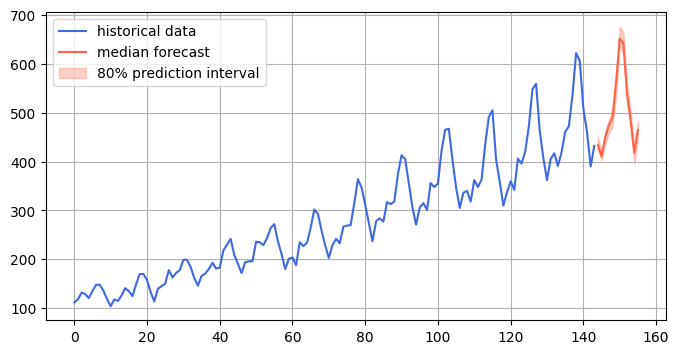

In [11]:
import torch
from chronos import ChronosPipeline

pipeline = ChronosPipeline.from_pretrained(
  "amazon/chronos-t5-small",
  device_map="cuda",
  torch_dtype=torch.bfloat16,
)
trainTimeSeriesDF = extractDF('hcml_projects/task_1/dataframes/raw_train.csv', 'ml4h_data/p1/Outcomes-a.txt')[1]
testTimeSeriesDF = extractDF('hcml_projects/task_1/dataframes/raw_test.csv', 'ml4h_data/p1/Outcomes-c.txt')[1]

In [12]:
print(trainTimeSeriesDF.iloc[0])

PatientID               132539.000000
Hour                         0.000000
ALP                         79.000000
ALT                         30.000000
AST                         44.000000
Age                         54.000000
Albumin                      3.000000
BUN                         19.000000
Bilirubin                    0.700000
Cholesterol                155.000000
Creatinine                   0.900000
DiasABP                     58.000000
FiO2                         0.500000
GCS                         15.000000
Gender                       0.000000
Glucose                    125.000000
HCO3                        24.000000
HCT                         31.050000
HR                          73.000000
Height                     170.200000
ICUType                      4.000000
K                            4.100000
Lactate                      1.700000
MAP                         78.000000
MechVent                     1.000000
Mg                           2.000000
NIDiasABP   

In [13]:
def getChronosEmbedding(timeSeriesDF, columns=['APACHE_II'], aggregation='mean'):
    embeddingTimeSeriesDF = pd.DataFrame(columns=['PatientID', 'Embedding'])
    for patient in timeSeriesDF['PatientID'].unique():
        embeddings = []
        emb = False        
        for column in columns:
            if column == 'PatientID' or column == 'Hour':
                continue
            context = torch.tensor(
                timeSeriesDF[timeSeriesDF['PatientID'] == patient][column].values,
                dtype=torch.long  # Convert to integer type
            ).to(pipeline.model.device)    
            if context.dim() == 1:
                context = context.unsqueeze(0)
            
            # Instead of forecasting, pass the context directly to the encoder
            with torch.no_grad():
                # For T5-based models like Chronos, the encoder returns hidden states for each time step.
                encoder_outputs = pipeline.model.model.encoder(context)
                # Extract the hidden states: shape [batch_size, sequence_length, hidden_dim]
                hidden_states = encoder_outputs.last_hidden_state

            timeseries_embedding = hidden_states.mean(dim=1)
            if(aggregation == 'none'):
                embedding_np = timeseries_embedding.cpu().to(torch.float32).numpy()[0]
                embeddings.append(embedding_np)
            
            elif not emb: 
                embedding_np = timeseries_embedding.cpu().to(torch.float32).numpy()[0]
                emb = True
            else:
                embedding_np += timeseries_embedding.cpu().to(torch.float32).numpy()[0]

        if aggregation == 'mean':
            embedding_np = embedding_np / len(columns)
            embeddingTimeSeriesDF = pd.concat([embeddingTimeSeriesDF, pd.DataFrame({'PatientID': [patient], 'Embedding': [embedding_np]})], ignore_index=True)

        elif aggregation == 'none':
            embeddings = np.array(embeddings)
            embeddingTimeSeriesDF = pd.concat([embeddingTimeSeriesDF, pd.DataFrame({'PatientID': [patient], 'Embeddings': [embeddings]})], ignore_index=True)

    return embeddingTimeSeriesDF

In [ ]:
columns = ['APACHE_II', 'SOFA', 'PF_Ratio', 'OxygenationIndex', 'BUN_Creatinine_Ratio', 'ShockIndex', 'MAP_Calc']
trainTSEmbeddingsDF = getChronosEmbedding(trainTimeSeriesDF, columns)
testTSEmbeddingsDF = getChronosEmbedding(testTimeSeriesDF, columns)

print(testTSEmbeddingsDF.head(1))

  PatientID                                          Embedding
0    152871  [0.044568744, -0.04699707, -0.024919782, -3.11...


In [13]:
TStrainDF = pd.merge(trainPatientsDF, trainTSEmbeddingsDF, on="PatientID")
TStrainDF = TStrainDF[['PatientID', 'Embedding', 'Death']]

TStestDF = pd.merge(testPatientsDF, testTSEmbeddingsDF, on="PatientID")
TStestDF = TStestDF[['PatientID', 'Embedding', 'Death']]

print(TStrainDF.head(5))
print(TStestDF.head(5))

  PatientID                                          Embedding  Death
0    132539  [0.0431039, -0.046962194, -0.023175921, -3.104...      0
1    132540  [0.044394355, -0.044887, -0.025652204, -3.0432...      0
2    132541  [0.043940954, -0.04762486, -0.023332868, -3.10...      0
3    132543  [0.04421997, -0.047101703, -0.023873465, -3.06...      0
4    132545  [0.045580182, -0.04333496, -0.02657645, -2.954...      0
  PatientID                                          Embedding  Death
0    152871  [0.044568744, -0.04699707, -0.024919782, -3.11...      0
1    152873  [0.043696813, -0.04748535, -0.023472378, -3.16...      1
2    152875  [0.0461513, -0.041748047, -0.026977539, -2.939...      0
3    152878  [0.044442315, -0.044172015, -0.024693081, -3.0...      0
4    152882  [0.039969306, -0.044799805, -0.022356305, -3.1...      0


(4000, 512) (4000, 512)
(4000,) (4000,)
Test Accuracy: 0.59275
Min probability: 0.30404426602891127 Max probability: 0.6093711333331446


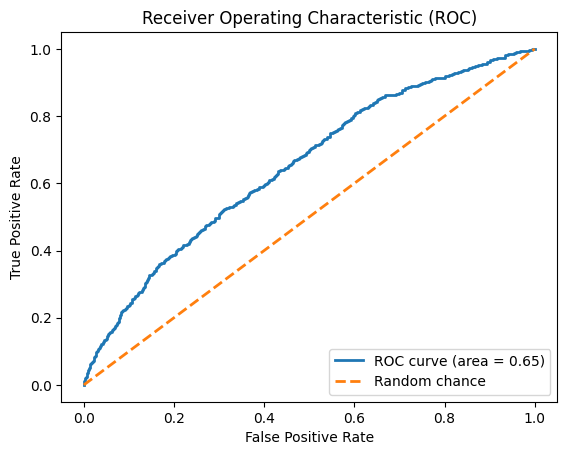

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc

X_train = np.array([np.array(x) for x in TStrainDF['Embedding']])
X_test = np.array([np.array(x) for x in TStestDF['Embedding']])
y_train = TStrainDF['Death'].values
y_test = TStestDF['Death'].values

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

model = LogisticRegression(max_iter=1000, class_weight='balanced')  # increase max_iter if needed
model.fit(X_train, y_train)

# Evaluate the model on the test set
# custom_threshold = 0.55
# y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
# custom_accuracy = accuracy_score(y_test, y_pred_custom)
print("Test Accuracy:", accuracy)
# print('Custom threshold accuracy: ', custom_accuracy)
# print(y_pred_custom, y_test)
# print(np.sum(y_pred==y_test))
# print(np.sum(y_pred_custom == 1))

y_pred_proba = model.predict_proba(X_test)[:, 1]
print("Min probability:", y_pred_proba.min(), "Max probability:", y_pred_proba.max())

# Compute the false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

In [42]:
columns = ['APACHE_II', 'SOFA', 'PF_Ratio', 'OxygenationIndex', 'BUN_Creatinine_Ratio', 'ShockIndex', 'MAP_Calc']
trainTSEmbeddingsDF = getChronosEmbedding(trainTimeSeriesDF, columns, aggregation='none')
testTSEmbeddingsDF = getChronosEmbedding(testTimeSeriesDF, columns, aggregation='none')

In [72]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

class SimpleAggregator(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        """
        input_dim: the dimension after concatenating all embeddings.
        hidden_dim: number of units in the hidden layer.
        output_dim: dimension of the output (e.g., 1 for binary classification).
        """
        super(SimpleAggregator, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

input_dim = 512*len(columns)
hidden_dim = 512
output_dim = 1

model = SimpleAggregator(input_dim, hidden_dim, output_dim)
optimizer = optim.Adam(model.parameters(), lr=1.5e-4)

# ------- Data preparation -------

TStrainDF = pd.merge(trainPatientsDF, trainTSEmbeddingsDF, on="PatientID")
TStrainDF = TStrainDF[['PatientID', 'Embeddings', 'Death']]
TStrainDF['Embeddings'] = TStrainDF['Embeddings'].apply(lambda x: np.array(x).flatten())
X_train = np.array([np.array(x) for x in TStrainDF['Embeddings']])
y_train = TStrainDF['Death'].values
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)  # Reshape to match output dimension

TStestDF = pd.merge(testPatientsDF, testTSEmbeddingsDF, on="PatientID")
TStestDF = TStestDF[['PatientID', 'Embeddings', 'Death']]
TStestDF['Embeddings'] = TStestDF['Embeddings'].apply(lambda x: np.array(x).flatten())
X_test = np.array([np.array(x) for x in TStestDF['Embeddings']])
y_test = TStestDF['Death'].values
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)  # Reshape to match output dimension

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

negatives_train = (TStrainDF['Death'] == 0).sum()
positives_train = (TStrainDF['Death'] == 1).sum()
pos_weight_value = negatives_train / positives_train
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32)

# ------- Loss function -------

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ------- Training -------

num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    for batch_data, batch_labels in train_loader:
        optimizer.zero_grad()
        
        outputs = model(batch_data)
        loss = criterion(outputs, batch_labels)
        
        loss.backward()
        optimizer.step()
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/100], Loss: 1.3809
Epoch [2/100], Loss: 1.3792
Epoch [3/100], Loss: 1.3734
Epoch [4/100], Loss: 1.3650
Epoch [5/100], Loss: 1.3553
Epoch [6/100], Loss: 1.3449
Epoch [7/100], Loss: 1.3347
Epoch [8/100], Loss: 1.3245
Epoch [9/100], Loss: 1.3142
Epoch [10/100], Loss: 1.3043
Epoch [11/100], Loss: 1.2948
Epoch [12/100], Loss: 1.2858
Epoch [13/100], Loss: 1.2775
Epoch [14/100], Loss: 1.2699
Epoch [15/100], Loss: 1.2629
Epoch [16/100], Loss: 1.2566
Epoch [17/100], Loss: 1.2510
Epoch [18/100], Loss: 1.2459
Epoch [19/100], Loss: 1.2414
Epoch [20/100], Loss: 1.2374
Epoch [21/100], Loss: 1.2338
Epoch [22/100], Loss: 1.2307
Epoch [23/100], Loss: 1.2280
Epoch [24/100], Loss: 1.2258
Epoch [25/100], Loss: 1.2239
Epoch [26/100], Loss: 1.2222
Epoch [27/100], Loss: 1.2208
Epoch [28/100], Loss: 1.2196
Epoch [29/100], Loss: 1.2184
Epoch [30/100], Loss: 1.2175
Epoch [31/100], Loss: 1.2166
Epoch [32/100], Loss: 1.2160
Epoch [33/100], Loss: 1.2154
Epoch [34/100], Loss: 1.2148
Epoch [35/100], Loss: 1

tensor([[ 0.2909],
        [ 0.1522],
        [-0.5686],
        ...,
        [-0.8401],
        [ 0.0830],
        [ 0.0618]])
              precision    recall  f1-score   support

         0.0       0.93      0.71      0.80      3415
         1.0       0.28      0.67      0.40       585

    accuracy                           0.70      4000
   macro avg       0.60      0.69      0.60      4000
weighted avg       0.83      0.70      0.74      4000

Min probability: 0.04192178 Max probability: 0.903331


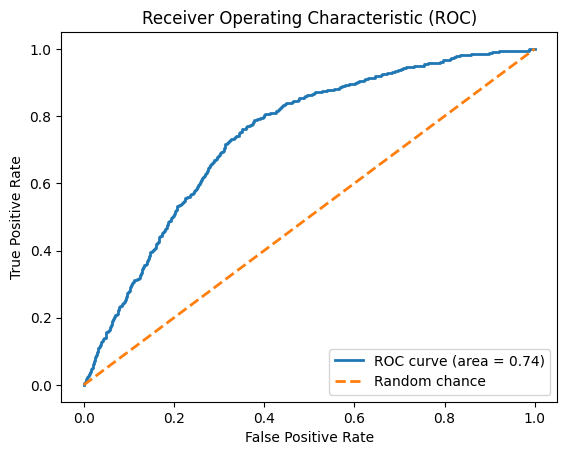

In [73]:
# ------- Evaluation -------
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    y_pred_proba = torch.sigmoid(outputs).numpy()
    predictions = (y_pred_proba > 0.5).astype(int)
    print(outputs)
    print(classification_report(y_test, predictions))
    print("Min probability:", y_pred_proba.min(), "Max probability:", y_pred_proba.max())

    # Compute the false positive rate, true positive rate, and thresholds
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    # Plot the ROC curve using matplotlib
    plt.figure()
    plt.plot(fpr, tpr, lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc='lower right')
    plt.show()